# Lab 7: Decision Tree Classification on the Iris Dataset


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
iris = load_iris()
X, y = iris.data, iris.target
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['target'] = y
iris_df['class'] = [iris.target_names[label] for label in y]

## Task 1: Dataset Exploration

In [18]:
print(f'Number of samples : {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print('\nFeature names:')
for name in iris.feature_names:
    print('-', name)
print('\nTarget classes:', list(iris.target_names))
print('\nFirst five records:')
display(iris_df.head())
print('Class distribution:')
class_distribution = iris_df['class'].value_counts().reindex(iris.target_names)
display(class_distribution.rename('count').to_frame())

Number of samples : 150
Number of features: 4

Feature names:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Class distribution:


,count
class,
setosa,50
versicolor,50
virginica,50


**Answer:** The dataset contains **150 samples and 4 features**. It is perfectly balanced: setosa, versicolor, and virginica each contain 50 samples.

## Task 2: Data Preparation

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print('Training set:', X_train.shape, y_train.shape)
print('Testing set :', X_test.shape, y_test.shape)

Training set: (120, 4) (120,)
Testing set : (30, 4) (30,)


The training set is used to learn the decision rules, while the testing set contains unseen data used to measure how well the trained model generalizes. Keeping the test data separate gives a less biased estimate of performance on future samples. The 80:20 split provides 120 samples for training and 30 for testing.

## Task 3: Building a Decision Tree Classifier

Accuracy Score: 1.0000

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



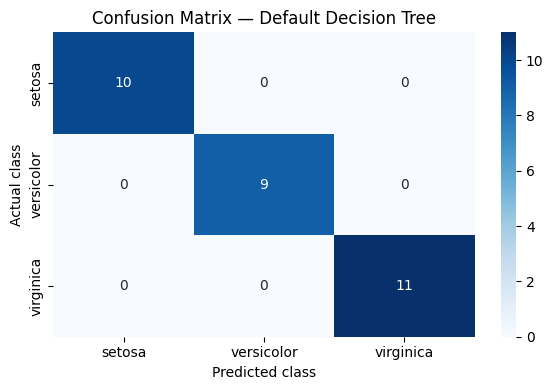

In [20]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)
y_pred = dt_default.predict(X_test)

print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Confusion Matrix — Default Decision Tree')
plt.tight_layout()
plt.show()

## Task 4: Visualizing the Decision Tree

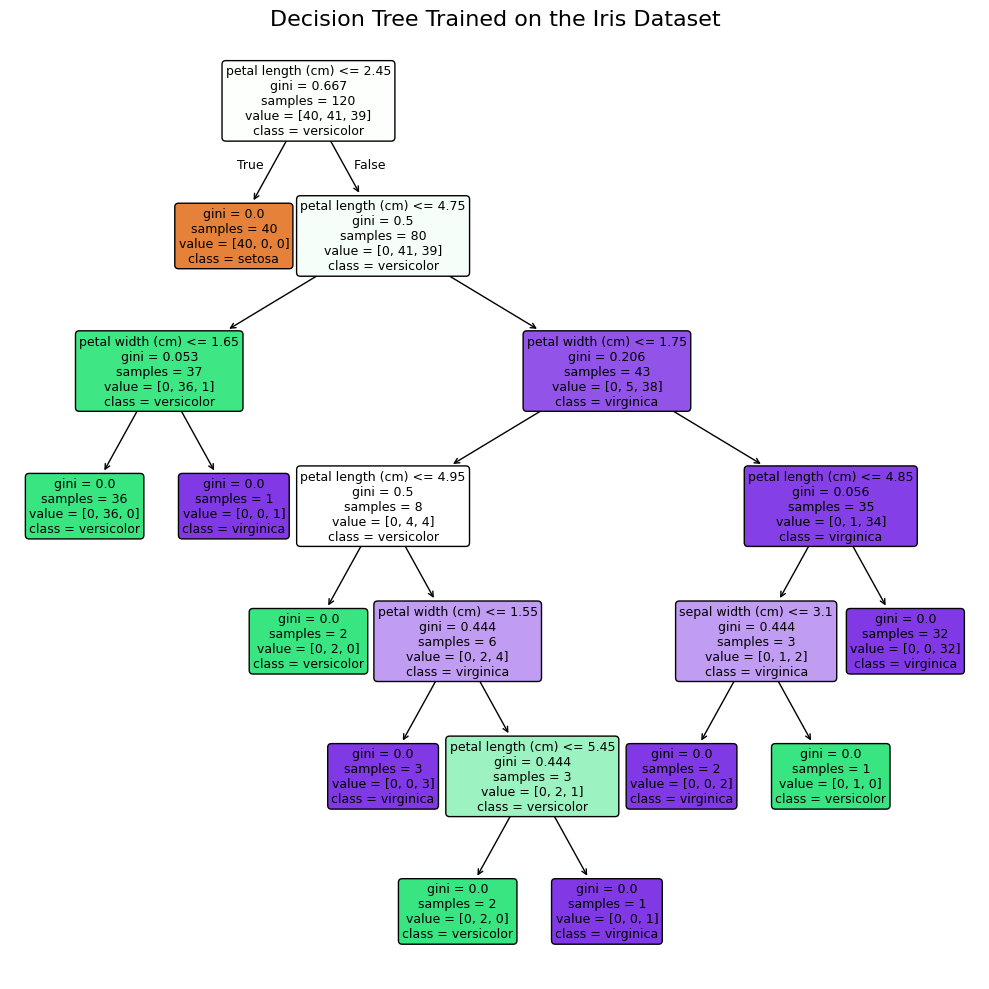

Root/first-split feature: petal length (cm)
Root threshold: 2.45
Maximum tree depth: 6
Number of leaf nodes: 10
Number of internal nodes: 9


In [21]:
plt.figure(figsize=(10, 10))
plot_tree(dt_default, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Trained on the Iris Dataset', fontsize=16)
plt.tight_layout()
plt.show()

root_index = dt_default.tree_.feature[0]
print('Root/first-split feature:', iris.feature_names[root_index])
print('Root threshold:', round(dt_default.tree_.threshold[0], 3))
print('Maximum tree depth:', dt_default.get_depth())
print('Number of leaf nodes:', dt_default.get_n_leaves())
print('Number of internal nodes:', dt_default.tree_.node_count - dt_default.get_n_leaves())

**Petal length** is selected for the first split. A Decision Tree examines candidate splits and chooses the one that produces the largest impurity reduction. The 2.45 cm split cleanly separates all setosa training samples from the other two classes, so it gives a strong reduction in Gini impurity.

## Task 5: Comparing Gini Index and Entropy

In [22]:
criterion_rows = []
criterion_models = {}
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    criterion_models[criterion] = model
    criterion_rows.append({
        'Criterion': criterion.title(),
        'Test Accuracy': model.score(X_test, y_test),
        'Tree Depth': model.get_depth(),
        'Leaf Nodes': model.get_n_leaves(),
        'Root Feature': iris.feature_names[model.tree_.feature[0]]
    })

criterion_results = pd.DataFrame(criterion_rows)
display(criterion_results.round({'Test Accuracy': 4}))

,Criterion,Test Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)


**Observation:** With this split and `random_state`, Gini and Entropy both obtain 1.0000 test accuracy, depth 6, 10 leaves, and select petal length for the root. Therefore, neither produces a structurally simpler tree in this experiment. Gini is often slightly faster to calculate because it does not use logarithms, but that computational difference is not visible in the tree-size table.

### Entropy at Every Node

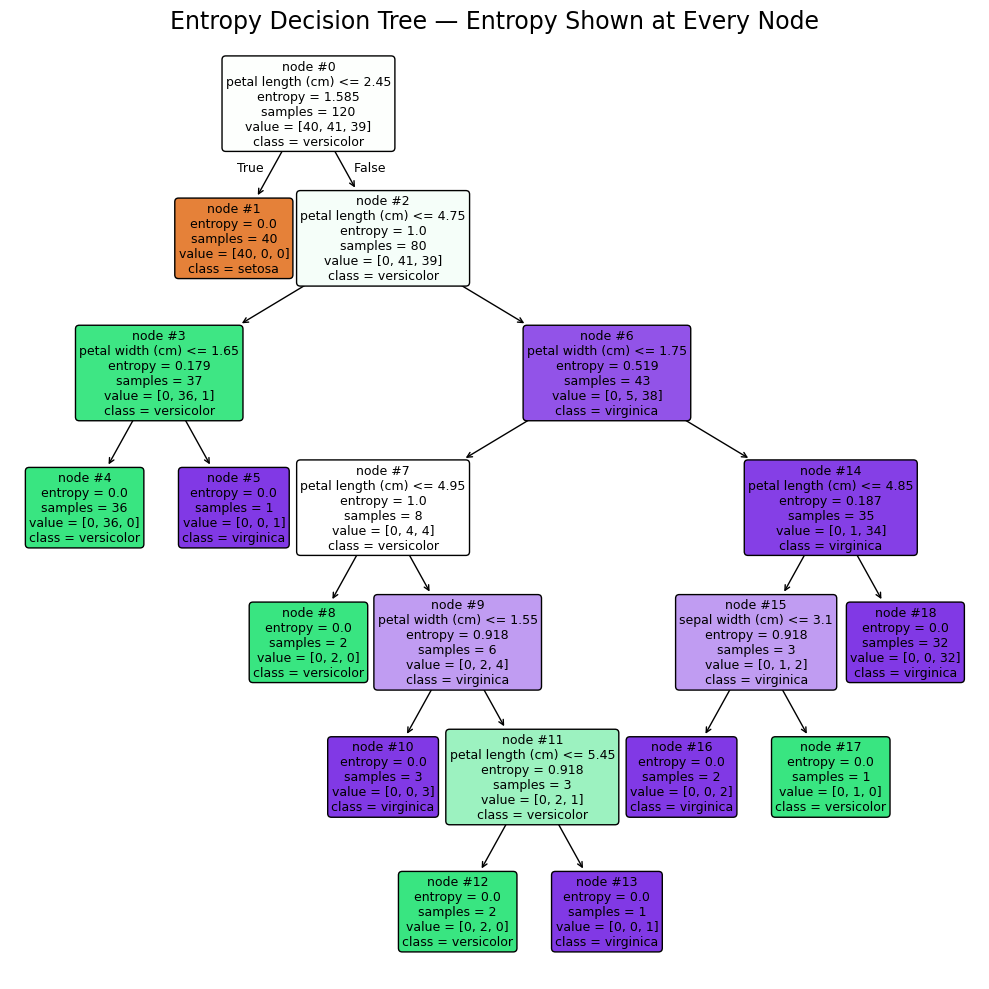

In [23]:
entropy_model = criterion_models['entropy']

# The tree itself: every box displays its node entropy.
plt.figure(figsize=(10, 10))
plot_tree(
    entropy_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    node_ids=True,
    fontsize=9
)
plt.title('Entropy Decision Tree — Entropy Shown at Every Node', fontsize=17)
plt.tight_layout()
plt.show()



## Task 6: Effect of Maximum Tree Depth

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6750,0.6333,1,Underfits; tree is too shallow
1,2,0.9500,0.9667,2,Simple tree with strong generalization
2,3,0.9583,1.0000,3,Best test accuracy with low complexity
3,4,0.9750,1.0000,4,Perfect test accuracy; slightly more complex
4,None,1.0000,1.0000,6,Fully grown; highest complexity and overfittin...


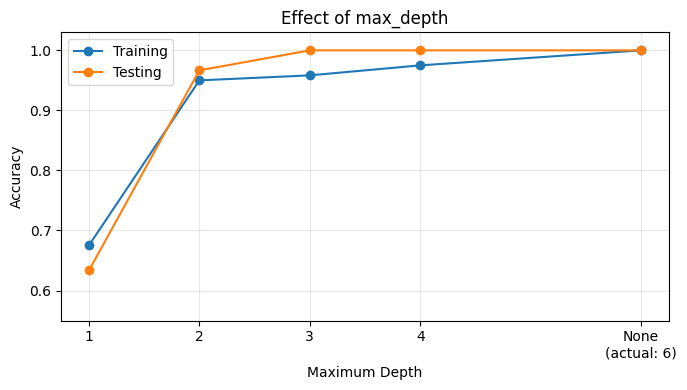

In [24]:
depth_rows = []
depth_observations = {
    1: 'Underfits; tree is too shallow',
    2: 'Simple tree with strong generalization',
    3: 'Best test accuracy with low complexity',
    4: 'Perfect test accuracy; slightly more complex',
    None: 'Fully grown; highest complexity and overfitting risk'
}
for max_depth in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    depth_rows.append({
        'Max Depth': str(max_depth),
        'Training Accuracy': model.score(X_train, y_train),
        'Testing Accuracy': model.score(X_test, y_test),
        'Tree Depth': model.get_depth(),
        'Observation': depth_observations[max_depth]
    })

depth_results = pd.DataFrame(depth_rows)
display(depth_results.round({'Training Accuracy': 4, 'Testing Accuracy': 4}))

plot_depth = [1, 2, 3, 4, 6]  # 6 is the depth learned when max_depth=None
plt.figure(figsize=(7, 4))
plt.plot(plot_depth, depth_results['Training Accuracy'], marker='o', label='Training')
plt.plot(plot_depth, depth_results['Testing Accuracy'], marker='o', label='Testing')
plt.xticks(plot_depth, ['1', '2', '3', '4', 'None\n(actual: 6)'])
plt.ylim(0.55, 1.03)
plt.xlabel('Maximum Depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

- **Underfitting:** max_depth=1, because both training (0.6750) and testing (0.6333) accuracy are low.
- **Best generalization:** max_depth=3. It achieves 1.0000 test accuracy with only depth 3 and 5 leaves; it is simpler than depth 4 or the unrestricted model.
- **Likely to overfit:** max_depth=None. It grows to depth 6 and memorizes the training data (1.0000 training accuracy). Its test accuracy happens to remain perfect on this small test set, but its extra branches do not improve test performance and increase variance, so it has the greatest overfitting risk.

## Task 7: Effect of `min_samples_split`

In [25]:
split_rows = []
for value in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=value, random_state=42)
    model.fit(X_train, y_train)
    split_rows.append({
        'min_samples_split': value,
        'Accuracy': model.score(X_test, y_test),
        'Tree Depth': model.get_depth(),
        'Leaf Nodes': model.get_n_leaves(),
        'Observation': ('Largest tree' if value == 2 else
                        'Tree becomes smaller' if value == 5 else
                        'Small tree; accuracy stays the same')
    })

split_results = pd.DataFrame(split_rows)
display(split_results.round({'Accuracy': 4}))

,min_samples_split,Accuracy,Tree Depth,Leaf Nodes,Observation
0,2,1.0,6,10,Largest tree
1,5,1.0,5,8,Tree becomes smaller
2,10,1.0,4,6,Small tree; accuracy stays the same
3,20,1.0,4,6,Small tree; accuracy stays the same


A larger min_samples_split means a node needs more samples before it can split. Therefore, the tree becomes smaller. Here, increasing the value from 2 to 10 reduced the depth from 6 to 4 and the leaves from 10 to 6. The accuracy stayed at 1.0. However, a value that is too large can make the tree underfit.

## Task 8: Effect of `min_samples_leaf`

In [26]:
leaf_rows = []
leaf_notes = {
    1: 'Largest tree; may overfit',
    2: 'Smaller tree; accuracy stays the same',
    5: 'Small tree; accuracy stays the same',
    10: 'Small tree; accuracy drops slightly'
}
for value in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=value, random_state=42)
    model.fit(X_train, y_train)
    leaf_rows.append({
        'min_samples_leaf': value,
        'Accuracy': model.score(X_test, y_test),
        'Tree Depth': model.get_depth(),
        'Leaf Nodes': model.get_n_leaves(),
        'Observation': leaf_notes[value]
    })

leaf_results = pd.DataFrame(leaf_rows)
display(leaf_results.round({'Accuracy': 4}))

,min_samples_leaf,Accuracy,Tree Depth,Leaf Nodes,Observation
0,1,1.0000,6,10,Largest tree; may overfit
1,2,1.0000,5,8,Smaller tree; accuracy stays the same
2,5,1.0000,4,6,Small tree; accuracy stays the same
3,10,0.9667,4,6,Small tree; accuracy drops slightly


min_samples_leaf is the minimum number of samples required in a leaf. A larger value prevents very small leaves, so the tree is less likely to memorize the training data. Values 2 and 5 made the tree smaller without changing its accuracy. At 10, the accuracy fell to 0.9667, so making the value too large can cause underfitting.

## Task 9: Final Answers and Recommendation

1. **Role of criterion:** It tells the tree how to choose the best split. Gini and Entropy both measure how mixed the classes are. The tree selects the split that separates the classes most clearly.

2. **Influence of max_depth:** A small depth creates a simple tree that may underfit. A very large depth creates a complex tree that may overfit. A medium depth can give a good balance.

3. **Why larger values produce simpler trees:** Larger min_samples_split and min_samples_leaf values stop the tree from creating branches with very few samples. This produces a smaller tree with fewer branches and leaves.

4. **Hyperparameter with the greatest impact:** max_depth had the biggest effect. Test accuracy increased from **0.6333 at depth 1** to **1.0000 at depth 3**. Changing min_samples_split did not change test accuracy, while min_samples_leaf changed it only slightly. Gini and Entropy gave the same result.

5. **Recommended model:** Use DecisionTreeClassifier(max_depth=3, random_state=42). It gives **1.0000 test accuracy** with only 5 leaves. It is simpler than the unrestricted tree, so it is easier to understand and less likely to overfit.